# VQE — Demo

Walks through `algorithms.vqe` end to end: build the hardware-efficient
ansatz for a small transverse-field Ising chain, visualize the circuit and
a per-term measurement histogram before parameter optimization, then
estimate the ground-state energy via `solve_ground_state()` and check it
against exact classical diagonalization.

See [../math.md](../math.md) for the theory — including why measuring a
general Hamiltonian needs per-term basis rotation, unlike
[algorithms/qaoa/](../../qaoa/)'s diagonal cost function — and
[../paper.md](../paper.md) for the circuit derivation this notebook
exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
import numpy as np

from algorithms.vqe import visualization
from algorithms.vqe.circuit import ansatz_circuit, measurement_circuit
from algorithms.vqe.execution import AerExecutor
from algorithms.vqe.hamiltonians import TransverseFieldIsingHamiltonian
from algorithms.vqe.implementation import expectation_value, solve_ground_state

# A 2-qubit transverse-field Ising chain: H = -J*Z0Z1 - h*(X0 + X1).
n_qubits = 2
hamiltonian = TransverseFieldIsingHamiltonian(n_qubits, j_coupling=1.0, h_field=0.5)
executor = AerExecutor()
print(f"Hamiltonian terms: {hamiltonian.terms}")

Hamiltonian terms: [PauliTerm(coefficient=-1.0, paulis='ZZ'), PauliTerm(coefficient=-0.5, paulis='XI'), PauliTerm(coefficient=-0.5, paulis='IX')]


## The ansatz circuit (unoptimized parameters)

`reps=1`: one layer of per-qubit `RY(theta)` plus an entangling `CX`, then
a final `RY` layer — 4 parameters total for 2 qubits.

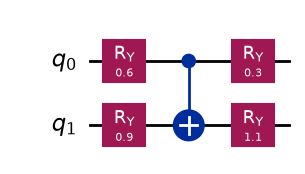

In [3]:
reps = 1
params = [0.6, 0.9, 0.3, 1.1]
circuit = ansatz_circuit(n_qubits, params, reps)
visualization.circuit_figure(circuit)

## Measuring one Hamiltonian term

Each non-identity Pauli term needs its own measurement circuit: the
ansatz, then that term's basis-rotation gates, then a measurement of every
qubit. Here's the `Z0*Z1` term's histogram under the arbitrary parameters
above.

Measuring term: PauliTerm(coefficient=-1.0, paulis='ZZ')
10:  572
00:  249
11:  177
01:    2


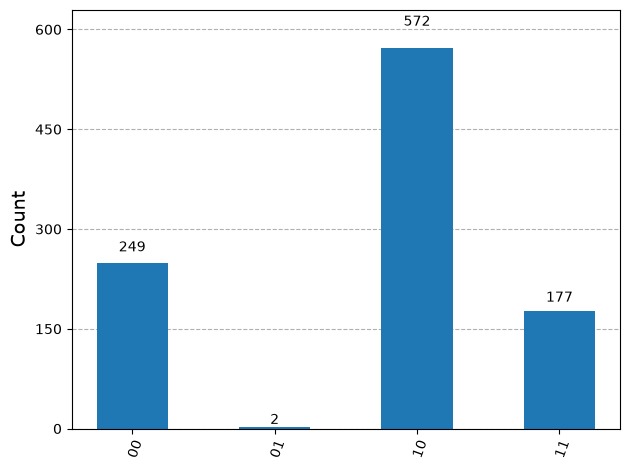

In [4]:
zz_term = hamiltonian.terms[0]
print(f"Measuring term: {zz_term}")
m_circuit = measurement_circuit(n_qubits, params, reps, zz_term)
counts = executor.run(m_circuit, shots=1000)
for bitstring, count in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"{bitstring}: {count:4d}")
visualization.plot_measurement_histogram(counts)

## `expectation_value`: combining all terms

Runs one measurement circuit per non-identity term and combines
counts-weighted `+-1` parities — this is `solve_ground_state`'s
objective, evaluated here at the same arbitrary (non-optimized)
parameters.

In [5]:
energy_estimate = expectation_value(hamiltonian, params, reps, shots=1000)
print(f"<H> at arbitrary params: {energy_estimate:.4f}")

<H> at arbitrary params: -0.5720


## `solve_ground_state`: the full classical-quantum loop

`scipy.optimize.minimize` (COBYLA) tunes the ansatz parameters against the
sampled expectation value, then a final higher-shot-count run re-estimates
the energy. Compared against the exact ground energy from classical
diagonalization of the Hamiltonian's matrix — feasible only because this
chain is small.

In [6]:
_, found_energy = solve_ground_state(hamiltonian, reps=reps)
print(f"Found energy: {found_energy:.4f}")

# Exact diagonalization for comparison (feasible only for small chains).
pauli_matrices = {
    "I": np.eye(2, dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}
dim = 2**n_qubits
matrix = np.zeros((dim, dim), dtype=complex)
for term in hamiltonian.terms:
    term_matrix = pauli_matrices[term.paulis[0]]
    for pauli in term.paulis[1:]:
        term_matrix = np.kron(term_matrix, pauli_matrices[pauli])
    matrix += term.coefficient * term_matrix
exact_energy = float(np.min(np.linalg.eigvalsh(matrix)))
print(f"Exact ground energy: {exact_energy:.4f}")

# The variational principle guarantees found_energy >= exact_energy.
assert found_energy >= exact_energy - 1e-9

Found energy: -1.3325
Exact ground energy: -1.4142
